# Data Quality Report - Part 1.B, 1.C, 1.D

Dataset: French Road Safety Open Data, year 2024.

Part 1.A (`01_data_profiling.ipynb`) covered what each column means. This
notebook asks a different question: how trustworthy is the data actually?
It looks at missing values, checks whether values fall in plausible ranges,
flags duplicate records, and closes with what all of that means for anyone
trying to run analysis on top of this dataset.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

BRONZE_DIR = Path("data/bronze")
FILES = ["caract-2024.csv", "lieux-2024.csv", "vehicules-2024.csv", "usagers-2024.csv"]

LAT_MIN, LAT_MAX = -22, 51
LON_MIN, LON_MAX = -63, 56

In [2]:
tables = {
    name: pd.read_csv(BRONZE_DIR / name, sep=";", encoding="utf-8", low_memory=False)
    for name in FILES
}
caract = tables["caract-2024.csv"]
lieux = tables["lieux-2024.csv"]
vehicules = tables["vehicules-2024.csv"]
usagers = tables["usagers-2024.csv"]

## B. Missing Values and Completeness

First pass: for each table, which columns actually have gaps, and how big
are they?

In [3]:
def missing_percentages(df):
    return (df.isna().sum() / len(df) * 100).round(2)

for name, df in tables.items():
    print(f"--- {name} ---")
    display(missing_percentages(df)[missing_percentages(df) > 0])

--- caract-2024.csv ---


adr    4.25
dtype: float64

--- lieux-2024.csv ---


voie      18.98
v2        91.58
lartpc    99.95
dtype: float64

--- vehicules-2024.csv ---


occutc    98.98
dtype: float64

--- usagers-2024.csv ---


an_nais    2.06
dtype: float64

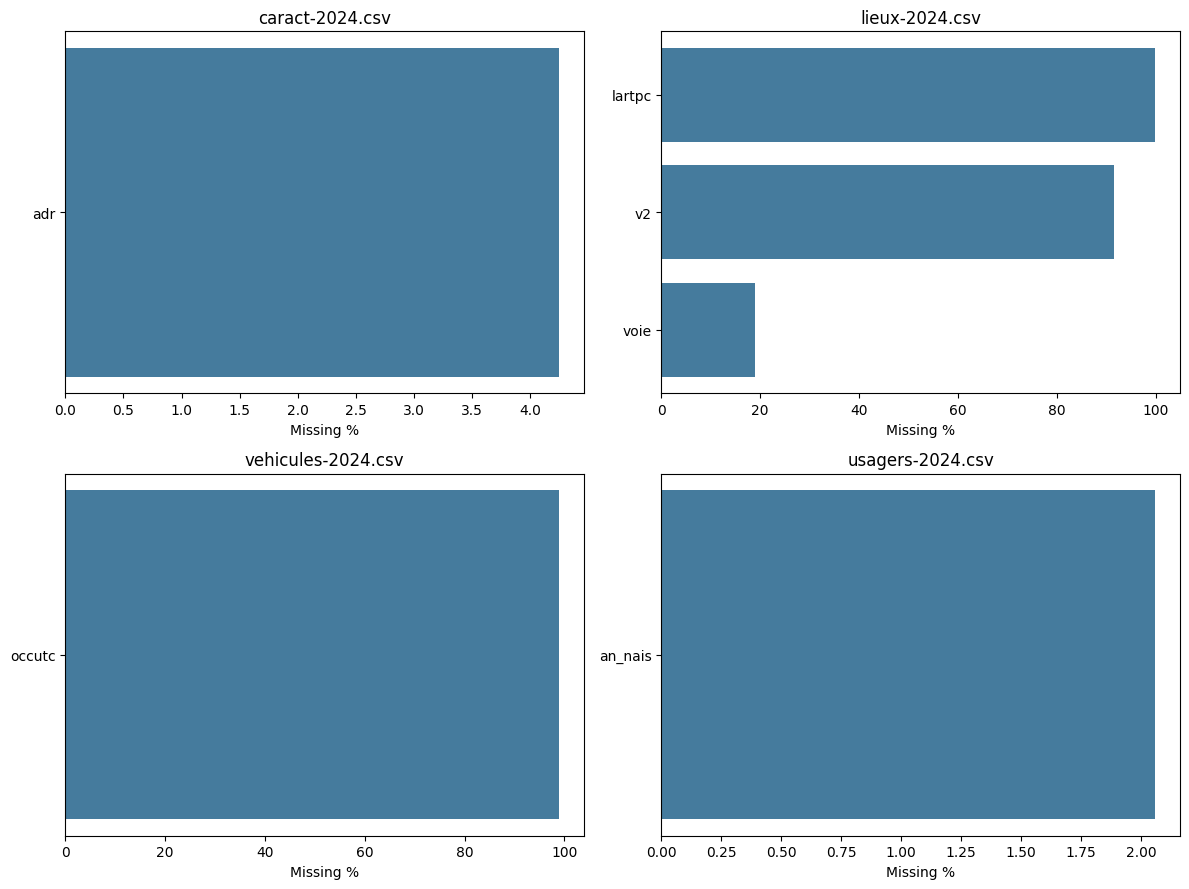

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, df) in zip(axes, tables.items()):
    missing_pct = missing_percentages(df)
    missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)
    if len(missing_pct) == 0:
        ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
        ax.set_title(name)
        continue
    ax.barh(missing_pct.index, missing_pct.values, color="#457B9D")
    ax.set_title(name)
    ax.set_xlabel("Missing %")

fig.tight_layout()
plt.show()

In [5]:
missing_birth_year = int(usagers["an_nais"].isna().sum())
an_nais_missing_pct = round(missing_birth_year / len(usagers) * 100, 2)
voie_missing_pct = round(lieux["voie"].isna().sum() / len(lieux) * 100, 2)
adr_missing_pct = round(caract["adr"].isna().sum() / len(caract) * 100, 2)

display(Markdown(f'''
The birth year column (`an_nais`) is the one gap that actually matters:
{missing_birth_year} users ({an_nais_missing_pct}%) have no birth year at all,
and since age is computed as accident year minus birth year, those users
simply cannot be part of any age-based comparison. Guessing an age for them
would be worse than excluding them, since a fabricated value would quietly
bias whichever age bracket absorbs it - so the right move is to drop them
from age-based aggregates and just note the smaller sample size.

By comparison, `voie` is missing {voie_missing_pct}% of the time in `lieux`,
and `adr` is missing {adr_missing_pct}% of the time in `caract`, but neither
really hurts the analysis: `dep`, `com`, `lat` and `long` already pin down
where the accident happened, so these two columns are nice-to-have context
rather than something worth imputing.

Then there is a batch of columns that look almost entirely empty - `v2`,
`lartpc` and `occutc` are missing more than 90% of the time - but that is not
really missing data, it is structural. `v2` and `lartpc` only apply to
specific road layouts, and `occutc` only applies to accidents involving a
public transport vehicle. Treating a 90%+ gap here as a red flag would be a
mistake; the right approach is to leave them blank and only pull them in when
specifically studying those subsets.

Finally, several categorical columns (`circ`, `vosp`, `prof`, `plan`, `surf`,
`infra`, `situ`, `senc`, `choc`, `motor`, `sexe`, `place`, `etatp`) use `-1`
as a code for "not specified". Pandas has no way of knowing that `-1` is
meant to behave like a missing value here - it is a perfectly valid integer -
so none of this shows up in the numbers above. It only becomes visible once
the values are checked against the official code list, which is what the
categorical anomalies check further down does. Before any of these columns
get used in analysis, `-1` needs to be recoded to an actual missing value,
which is exactly what the Silver layer notebook does.
'''))


The birth year column (`an_nais`) is the one gap that actually matters:
2579 users (2.06%) have no birth year at all,
and since age is computed as accident year minus birth year, those users
simply cannot be part of any age-based comparison. Guessing an age for them
would be worse than excluding them, since a fabricated value would quietly
bias whichever age bracket absorbs it - so the right move is to drop them
from age-based aggregates and just note the smaller sample size.

By comparison, `voie` is missing 18.98% of the time in `lieux`,
and `adr` is missing 4.25% of the time in `caract`, but neither
really hurts the analysis: `dep`, `com`, `lat` and `long` already pin down
where the accident happened, so these two columns are nice-to-have context
rather than something worth imputing.

Then there is a batch of columns that look almost entirely empty - `v2`,
`lartpc` and `occutc` are missing more than 90% of the time - but that is not
really missing data, it is structural. `v2` and `lartpc` only apply to
specific road layouts, and `occutc` only applies to accidents involving a
public transport vehicle. Treating a 90%+ gap here as a red flag would be a
mistake; the right approach is to leave them blank and only pull them in when
specifically studying those subsets.

Finally, several categorical columns (`circ`, `vosp`, `prof`, `plan`, `surf`,
`infra`, `situ`, `senc`, `choc`, `motor`, `sexe`, `place`, `etatp`) use `-1`
as a code for "not specified". Pandas has no way of knowing that `-1` is
meant to behave like a missing value here - it is a perfectly valid integer -
so none of this shows up in the numbers above. It only becomes visible once
the values are checked against the official code list, which is what the
categorical anomalies check further down does. Before any of these columns
get used in analysis, `-1` needs to be recoded to an actual missing value,
which is exactly what the Silver layer notebook does.


## C. Consistency and Validity Checks

### Value ranges: coordinates

Every accident has a latitude and longitude, but that does not mean every
coordinate is actually usable.

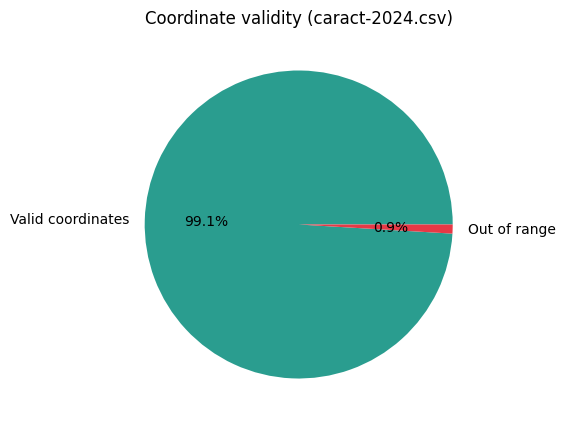

Valid coordinates: 53888
Out of range coordinates: 514


In [6]:
lat = pd.to_numeric(caract["lat"].astype(str).str.replace(",", "."), errors="coerce")
lon = pd.to_numeric(caract["long"].astype(str).str.replace(",", "."), errors="coerce")
out_of_range_coords = int((~lat.between(LAT_MIN, LAT_MAX) | ~lon.between(LON_MIN, LON_MAX)).sum())
valid_coords = len(caract) - out_of_range_coords

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    [valid_coords, out_of_range_coords],
    labels=["Valid coordinates", "Out of range"],
    autopct="%1.1f%%",
    colors=["#2A9D8F", "#E63946"],
)
ax.set_title("Coordinate validity (caract-2024.csv)")
plt.show()

print(f"Valid coordinates: {valid_coords}")
print(f"Out of range coordinates: {out_of_range_coords}")

### Value ranges: age

Age is not a column in the raw data - it has to be derived from
`an - an_nais` - so it is worth checking the result actually makes sense
before trusting it anywhere downstream.

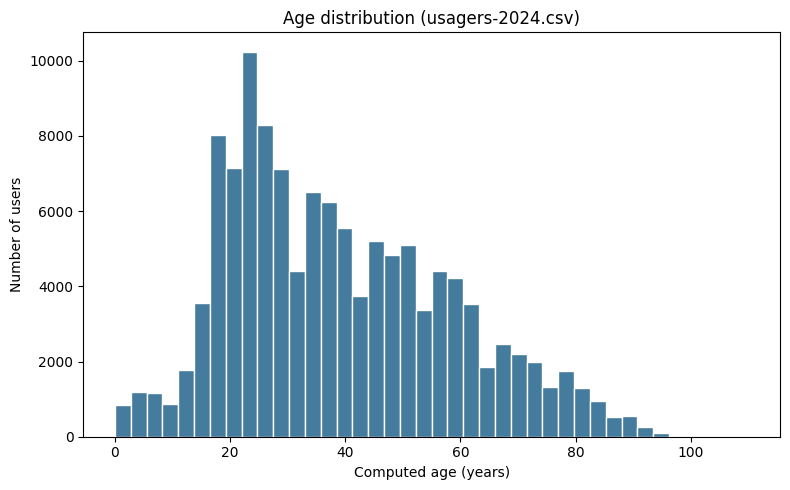

Missing birth year: 2579
Negative computed age: 0
Unrealistic computed age (> 110 years): 0


In [7]:
birth_year = pd.to_numeric(usagers["an_nais"], errors="coerce")
age = 2024 - birth_year

negative_age = int((age < 0).sum())
unrealistic_age = int((age > 110).sum())

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(age.dropna(), bins=40, color="#457B9D", edgecolor="white")
ax.set_xlabel("Computed age (years)")
ax.set_ylabel("Number of users")
ax.set_title("Age distribution (usagers-2024.csv)")
fig.tight_layout()
plt.show()

print(f"Missing birth year: {missing_birth_year}")
print(f"Negative computed age: {negative_age}")
print(f"Unrealistic computed age (> 110 years): {unrealistic_age}")

### Categorical anomalies

Every categorical column is documented with a fixed list of valid codes.
Anything outside that list is either a genuine data error or, more often
here, the `-1` "not specified" code hiding in a column where it is not
part of the official list.

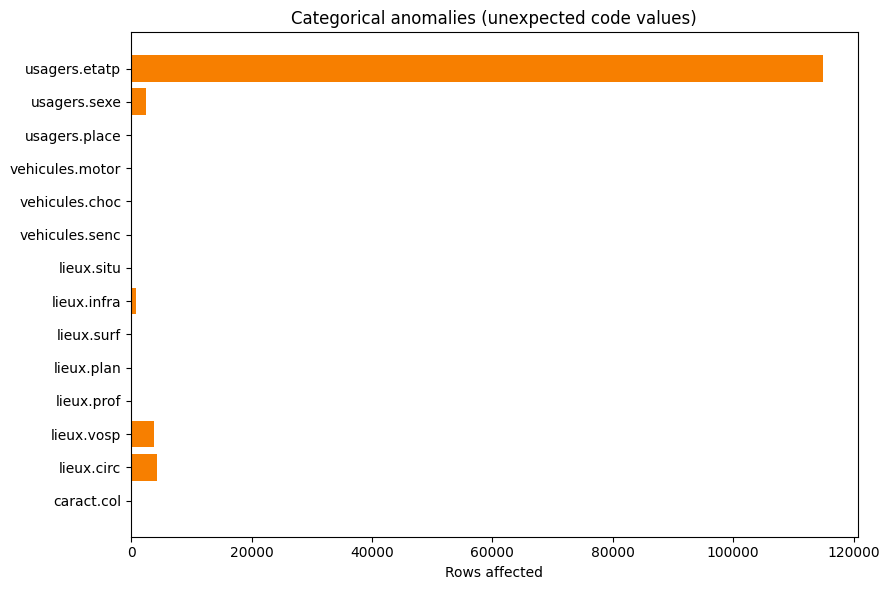

In [8]:
EXPECTED_CATEGORIES = {
    "caract-2024.csv": {
        "lum": [1, 2, 3, 4, 5],
        "agg": [1, 2],
        "int": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "atm": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "col": [1, 2, 3, 4, 5, 6, 7],
    },
    "lieux-2024.csv": {
        "catr": [1, 2, 3, 4, 5, 6, 7, 9],
        "circ": [1, 2, 3, 4],
        "vosp": [0, 1, 2, 3],
        "prof": [1, 2, 3, 4],
        "plan": [1, 2, 3, 4],
        "surf": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "infra": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        "situ": [0, 1, 2, 3, 4, 5, 6, 7, 8],
    },
    "vehicules-2024.csv": {
        "senc": [0, 1, 2, 3],
        "choc": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
        "motor": [0, 1, 2, 3, 4, 5, 6],
    },
    "usagers-2024.csv": {
        "place": list(range(1, 11)),
        "catu": [1, 2, 3, 4],
        "grav": [1, 2, 3, 4],
        "sexe": [1, 2],
        "etatp": [1, 2, 3],
    },
}

anomalies = {}
for name, categories in EXPECTED_CATEGORIES.items():
    df = tables[name]
    for col, allowed in categories.items():
        values = pd.to_numeric(df[col], errors="coerce")
        invalid = values[values.notna() & ~values.isin(allowed)]
        if len(invalid) > 0:
            anomalies[f"{name.split('-')[0]}.{col}"] = len(invalid)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(list(anomalies.keys()), list(anomalies.values()), color="#F77F00")
ax.set_xlabel("Rows affected")
ax.set_title("Categorical anomalies (unexpected code values)")
fig.tight_layout()
plt.show()

### Duplicates

Two different kinds of duplication are worth checking separately: rows
that are byte-for-byte identical, and rows that share the same `Num_Acc`
even though each accident is only supposed to appear once.

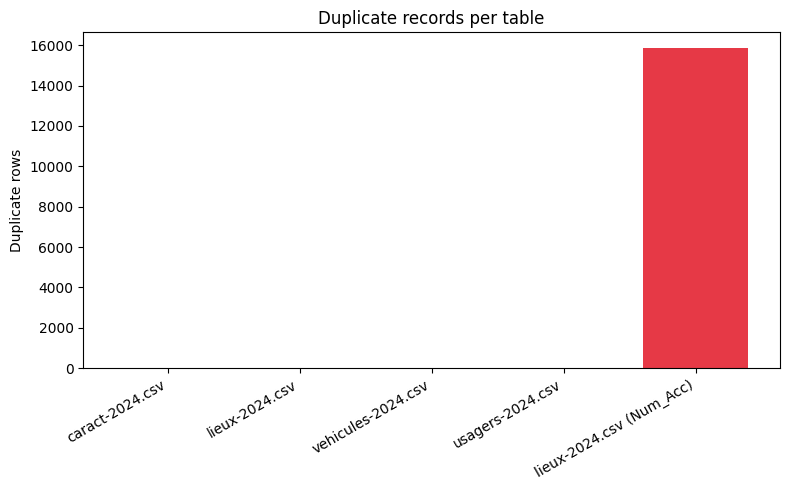

caract-2024.csv: 0 duplicate rows
lieux-2024.csv: 2 duplicate rows
vehicules-2024.csv: 0 duplicate rows
usagers-2024.csv: 0 duplicate rows
lieux-2024.csv (Num_Acc): 15846 duplicate rows


In [9]:
duplicate_counts = {name: int(df.duplicated().sum()) for name, df in tables.items()}
duplicate_counts["lieux-2024.csv (Num_Acc)"] = int(lieux["Num_Acc"].duplicated().sum())

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(duplicate_counts.keys(), duplicate_counts.values(), color="#E63946")
ax.set_ylabel("Duplicate rows")
ax.set_title("Duplicate records per table")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

for name, count in duplicate_counts.items():
    print(f"{name}: {count} duplicate rows")

## D. Data Quality Summary and Impact Analysis

In [10]:
display(Markdown(f'''
Putting the checks above together, three issues stand out more than the
rest. The biggest one is structural: `lieux` is supposed to have exactly one
row per accident, but {duplicate_counts["lieux-2024.csv (Num_Acc)"]} rows
share a `Num_Acc` that already appears elsewhere in the table. Left alone,
that means joining `caract` with `lieux` on `Num_Acc` would silently
duplicate accidents, which would inflate every count and every severity
aggregate built downstream - so this has to be resolved before any join, by
keeping a single row per accident.

The second is geographic: {out_of_range_coords} records in `caract` have
coordinates that fall outside a plausible bounding box for France (mainland
and overseas territories combined), which would place them somewhere in the
ocean or on another continent. On a map these points would show up as
obviously wrong markers, so they need to be treated as missing rather than
plotted as-is.

The third is the `-1` "not specified" code discussed earlier, which shows up
across several categorical columns (`etatp` being the most extreme example,
since it is `-1` for almost every user because it only applies to
pedestrians). If these codes are treated as a real category instead of a
missing value, any percentage-based conclusion - "most accidents happen in
X weather", "most vehicles are of type Y" - risks being skewed by an
artificial "not specified" bucket sitting alongside the real answers.

None of these are reasons to distrust the dataset as a whole; they are
exactly the kind of thing a Silver layer is meant to clean up before the
data is used for real analysis - which is the subject of the next notebook.
'''))


Putting the checks above together, three issues stand out more than the
rest. The biggest one is structural: `lieux` is supposed to have exactly one
row per accident, but 15846 rows
share a `Num_Acc` that already appears elsewhere in the table. Left alone,
that means joining `caract` with `lieux` on `Num_Acc` would silently
duplicate accidents, which would inflate every count and every severity
aggregate built downstream - so this has to be resolved before any join, by
keeping a single row per accident.

The second is geographic: 514 records in `caract` have
coordinates that fall outside a plausible bounding box for France (mainland
and overseas territories combined), which would place them somewhere in the
ocean or on another continent. On a map these points would show up as
obviously wrong markers, so they need to be treated as missing rather than
plotted as-is.

The third is the `-1` "not specified" code discussed earlier, which shows up
across several categorical columns (`etatp` being the most extreme example,
since it is `-1` for almost every user because it only applies to
pedestrians). If these codes are treated as a real category instead of a
missing value, any percentage-based conclusion - "most accidents happen in
X weather", "most vehicles are of type Y" - risks being skewed by an
artificial "not specified" bucket sitting alongside the real answers.

None of these are reasons to distrust the dataset as a whole; they are
exactly the kind of thing a Silver layer is meant to clean up before the
data is used for real analysis - which is the subject of the next notebook.
